# Identifying Potential Starbucks Hotspots in the Contiguous United States (CONUS)

## Imports

In [20]:
import duckdb
import geopandas as gdf
import numpy as np
from libpysal.weights import Queen
from esda.moran import Moran_Local
import matplotlib.pyplot as plt
import matplotlib.colors as colors

## Initial Visualization

<Axes: >

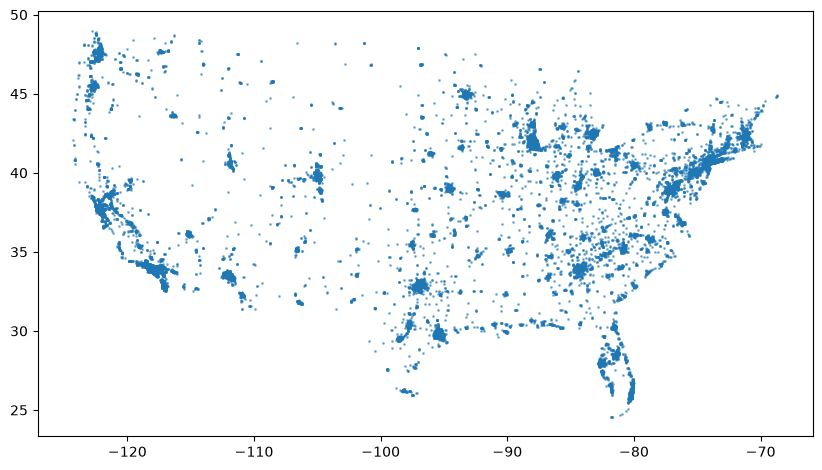

In [ ]:
# starbucks point data from osmnx

starbucks = gdf.read_parquet('data/usa_starbucks_with_geometry.parquet')
for name in ['AK', 'HI', 'PR']:
    starbucks = starbucks[starbucks['state'] != name]
starbucks.plot(figsize=(10, 10), markersize=1, alpha=0.5)

<Axes: >

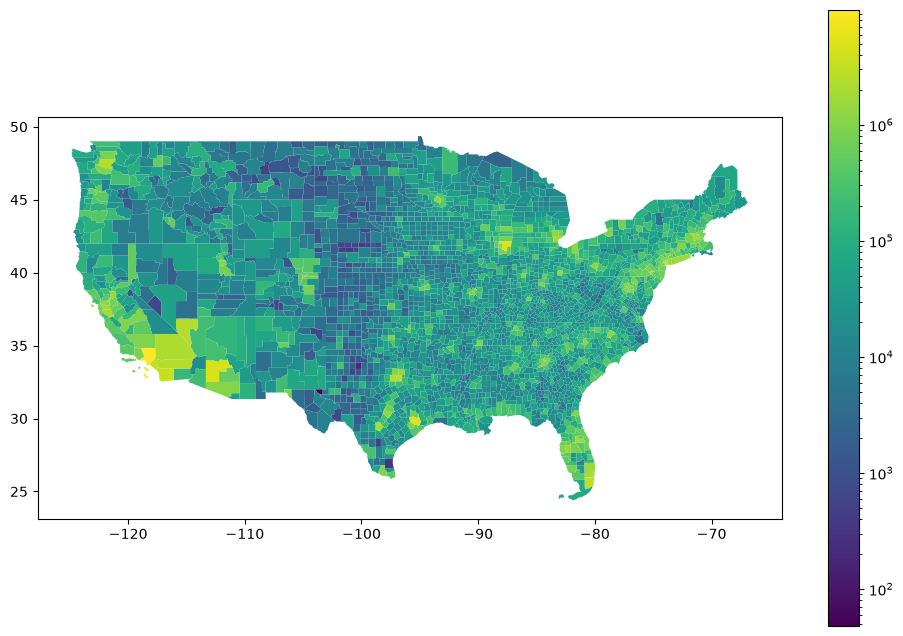

In [22]:
# counties polygon data from census TIGER/Line shapefiles

counties = gdf.read_parquet('data/us_county_population_with_geometry.parquet')
for state in ['Alaska', 'Hawaii', 'Puerto Rico']:
    counties = counties[counties['state_name'] != state]

counties.plot(
    column='pop_2024',
    cmap='viridis',
    legend=True,
    norm=colors.LogNorm(vmin=counties['pop_2024'].min(), vmax=counties['pop_2024'].max()),
    figsize=(12, 8)
)

## Prepare Data

In [15]:
# code here...